# ????????? ???????: Home Credit Default Risk

**????:** ??????????????? ??????????? ??????? ?? ?????? ?? ?????? ? ???????? ???????????????? ???????????? ?????? ? MLP. ???????????? ????????? ?? ?????? ???????? [Home Credit Default Risk](https://www.kaggle.com/competitions/home-credit-default-risk/overview).

> ??????? ??????????? ??? ??????????????? ????????????: EDA, ???????? ????????, ??????? ?? ?????????, ?????????? ??????? ? ?????? ???? ? ??????????? ??????? ??????. ??? ????????? ?????????????? ???????? ? CV-?????????, ????? ????????? ?????? ??????? ??????????.

## tl;dr

???? ?????? ??????????? ????? ?????????? ?????-????????? ? ?????????? ???????. ? ??? ????? ????????? ?????????? ROC-AUC, ????????? ???????, ???????? SHAP-???????, ????????? fairness-???????? ? ?????? ?? ???????? ???? ??? Kaggle.

## Context & Methods

### ??????????

??????? ?????????? `TARGET=1` ????????, ??? ? ??????? ???? ????????? ? ???????? ???????. ??? ?????????????????? ???????? ?????????????, ??????? ???????? ???????? ???????? ? **ROC-AUC**, ??????????? ? ???????? ????????????. ????????????? ?????????????? PR-AUC, F1 ??? ??????? ????????? ??????, Brier score ? ????? ????????.

### Key Assumptions

- ???????? ??????? ??????? ? ???? ?????? (`SK_ID_CURR`), ? ?? ????????? ???????? ?? ??????????????? ??????.
- ??? ?????? ???????? ???????????? ?????????? ?????????????????? 5-fold CV; ???? Kaggle ???????? ?????????? ?? ?????????? ????????.
- ???????? ? ???????????? ????????????? ?????? (????????, ?????????? ??????? ??? ???????? ????????), ??????? ?????????? ????????? ???????????.
- `DAYS_EMPLOYED=365243` ? ??????????? ????????, ??? ?????? ?????????? ??? ???????? ????.
- ??? ? ??????? ???????????? ?????? ??? ??????????????? fairness-????????; ??????? ?? ?????? ????? ????????? ?? ????? ? ?????????? ?????????, ? ?? ?? ????????????? ? ???????????.

### ??????? ????????

1. ??????? ??????????? ???????? `EXT_SOURCE_*` ? ??????? ?????????? ???????? ????? ???????? ??????? ??? ??????? ?????? ?? ??????.
2. ??????????? ??????, ??????? ? ????????? ????? ???????? ????????? ????????, ??? ?????????? ?????.
3. ???????? ? ??????????? ???? ????? ??????????????? ?????? ? ?????? ?????????????? ????.
4. ??????? ???????? ?????????? ????????? ?????? ? ???????? ??????, ? MLP ????? ?????????????????? ?????? ????? ?????????????? ? ?????????????.

## 1. Setup

??? ????????? ??????? ? ????? ??????. ?? ????????? ?????? ????? ?? ?????????? ???? ??? ????????????? ??????? ?? ????: ?????????????? ???????? ???????? ? ?????? ?? ???????? CSV. `FAST_MODE` ????? ?????? ??? ??????? ???????? ??????; ??? ?????????? ??????? ? ??????? ?? ?????? ???? `False`.

In [1]:
from pathlib import Path
from time import perf_counter
import gc
import json
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display, Markdown

RANDOM_STATE = 2026
FAST_MODE = False
FAST_NROWS = 250_000  # ?????? ??? smoke-?????; ?????? ?????? ?????? ??? ??????
N_SPLITS = 5
DATA_DIR = Path('../data/raw')
FIGURES_DIR = Path('../reports/figures')
SUBMISSIONS_DIR = Path('../submissions')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook', palette='deep')

assert (DATA_DIR / 'application_train.csv').exists(), f'??? ?????: {DATA_DIR / "application_train.csv"}'
print(f'???????? ??????: {DATA_DIR.resolve()}')
print(f'?????: {"??????? ????????" if FAST_MODE else "?????? ??????????????? ??????"}; folds={N_SPLITS}')

???????? ??????: C:\Users\kosti\OneDrive\Документы\projects\projects_ml\projects\04_home_credit_scoring\data\raw
?????: ?????? ??????????????? ??????; folds=5


## 2. Data

### 2.1. ?????????????? ?????? ? ???????? ??????? ??????

????? ?????????????? ????????? ??????? ????????, ????????????? ???????? ???????, ???????????? ??????????????, ?????? ??????, ??????????? ???????? ? ????????? ???????? ?????????? ?????. ??? ?????: ?????? ?? ?????? ????? ??? ?????? ????? ? ?????-????????? ????? ???? ????????? ???????, ?? ???????? ROC-AUC.

In [2]:
raw_files = (
    pd.DataFrame([
        {'file': path.name, 'size_mb': path.stat().st_size / 1024**2}
        for path in sorted(DATA_DIR.glob('*.csv'))
    ])
    .sort_values('size_mb', ascending=False)
    .reset_index(drop=True)
)
display(raw_files.style.format({'size_mb': '{:.1f}'}).set_caption('????? ???????? ????????'))

application_train = pd.read_csv(DATA_DIR / 'application_train.csv')
application_test = pd.read_csv(DATA_DIR / 'application_test.csv')

profile = pd.Series({
    '????? ? train': len(application_train),
    '???????? ? train': application_train.shape[1],
    '????? ? test': len(application_test),
    '???????? ? test': application_test.shape[1],
    '?????????? SK_ID_CURR ? train': application_train['SK_ID_CURR'].duplicated().sum(),
    '???? TARGET=1': application_train['TARGET'].mean(),
    '??????????? DAYS_EMPLOYED=365243': (application_train['DAYS_EMPLOYED'] == 365243).sum(),
})
display(profile.to_frame('????????'))

assert application_train['SK_ID_CURR'].is_unique, '???????? ???????????? ?????? ? train'
assert application_test['SK_ID_CURR'].is_unique, '???????? ???????????? ?????? ? test'
assert set(application_train.columns) - {'TARGET'} == set(application_test.columns), '????? train/test ???????????'
print('??????? ???????? ????????????? ? ????? ????????.')

,file,size_mb
0,installments_payments.csv,689.6
1,credit_card_balance.csv,404.9
2,previous_application.csv,386.2
3,POS_CASH_balance.csv,374.5
4,bureau_balance.csv,358.2
5,bureau.csv,162.1
6,application_train.csv,158.4
7,application_test.csv,25.3
8,sample_submission.csv,0.5
9,HomeCredit_columns_description.csv,0.0


,????????
????? ? train,"307,511.0000"
???????? ? train,122.0000
????? ? test,"48,744.0000"
???????? ? test,121.0000
?????????? SK_ID_CURR ? train,0.0000
???? TARGET=1,0.0807
??????????? DAYS_EMPLOYED=365243,"55,374.0000"


??????? ???????? ????????????? ? ????? ????????.


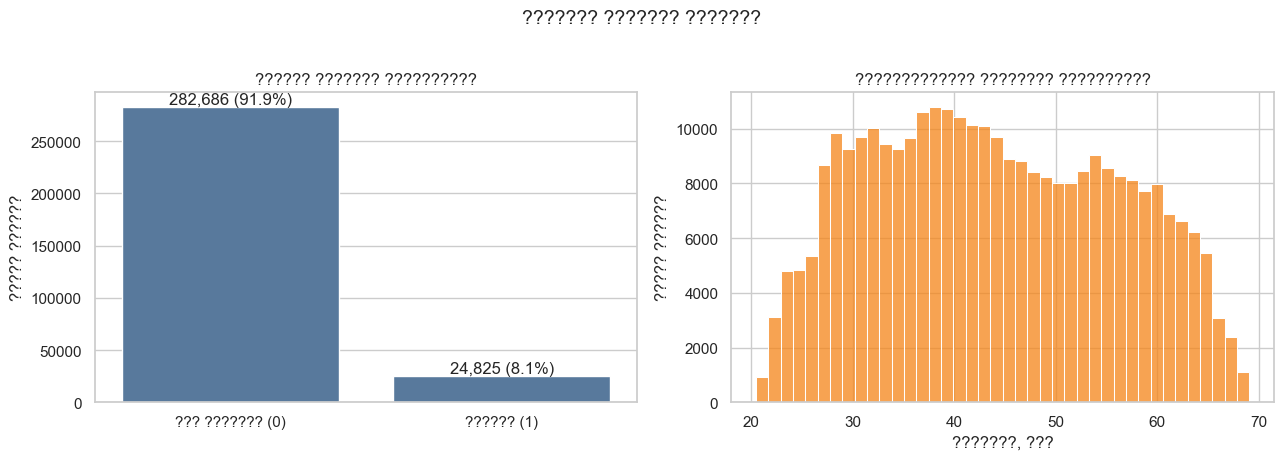

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

target_counts = application_train['TARGET'].value_counts().sort_index()
sns.barplot(x=['??? ??????? (0)', '?????? (1)'], y=target_counts.values, ax=axes[0], color='#4C78A8')
axes[0].set(title='?????? ??????? ??????????', xlabel='', ylabel='????? ??????')
for i, value in enumerate(target_counts.values):
    axes[0].text(i, value, f'{value:,} ({value / len(application_train):.1%})', ha='center', va='bottom')

age = -application_train['DAYS_BIRTH'] / 365.25
sns.histplot(age, bins=40, color='#F58518', ax=axes[1])
axes[1].set(title='????????????? ???????? ??????????', xlabel='???????, ???', ylabel='????? ??????')
fig.suptitle('??????? ??????? ???????', y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_target_and_age.png', dpi=160, bbox_inches='tight')
plt.show()

**????????????? ??????????.** ???? ???????? ???????? ???? (????? 8%), ??????? accuracy ?????? ???????????? ??? ??????? ???????: ??????????? ?????? ??????? 0? ????? ????????? ????????? ??????. ? ?????? ????? ???? ????????? ????? ???????? ???? `XNA` ? ??????????? ???????? ????? `365243`; ?? ????????? ????? ????? ? ???????????????.

### 2.2. ????????, ???? ????????? ? ?????????? ????????

????????? ?? ?????? ?????????? ?????????, ?? ? ?? ????????????? ???????????????. ??? ?????????? ???????? ?????????? ???????? ? ?????, ??????? ???????? ??? ??????? ????? ??????????????? ???????, ??????? ?? ????? ????????????? ??????????? ?????????? missingness.

In [4]:
feature_types = application_train.drop(columns='TARGET').dtypes.value_counts().rename_axis('dtype').reset_index(name='n_features')
display(feature_types)

missingness = (
    application_train.drop(columns='TARGET').isna().mean().sort_values(ascending=False).rename('missing_rate').to_frame()
)
missingness['missing_count'] = (missingness['missing_rate'] * len(application_train)).round().astype(int)
display(missingness.head(20).style.format({'missing_rate': '{:.1%}'}).set_caption('20 ????????? ? ?????????? ????? ?????????'))

key_numeric = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_EMPLOYED', 'DAYS_BIRTH']
summary_numeric = application_train[key_numeric].describe(percentiles=[.01, .05, .5, .95, .99]).T
display(summary_numeric)

quality_checks = pd.DataFrame({
    'check': ['????????????? ?????', '???????/????????????? ??????', '???????/????????????? ????????', '??????? < 18', '??????? > 100', 'XNA ? CODE_GENDER'],
    'count': [
        (application_train['AMT_INCOME_TOTAL'] <= 0).sum(),
        (application_train['AMT_CREDIT'] <= 0).sum(),
        (application_train['AMT_ANNUITY'].fillna(1) <= 0).sum(),
        ((-application_train['DAYS_BIRTH'] / 365.25) < 18).sum(),
        ((-application_train['DAYS_BIRTH'] / 365.25) > 100).sum(),
        (application_train['CODE_GENDER'] == 'XNA').sum(),
    ],
})
quality_checks['rate'] = quality_checks['count'] / len(application_train)
display(quality_checks.style.format({'rate': '{:.3%}'}))

,dtype,n_features
0,float64,65
1,int64,40
2,object,16


,missing_rate,missing_count
COMMONAREA_AVG,69.9%,214865
COMMONAREA_MODE,69.9%,214865
COMMONAREA_MEDI,69.9%,214865
NONLIVINGAPARTMENTS_AVG,69.4%,213514
NONLIVINGAPARTMENTS_MODE,69.4%,213514
NONLIVINGAPARTMENTS_MEDI,69.4%,213514
FONDKAPREMONT_MODE,68.4%,210295
LIVINGAPARTMENTS_MEDI,68.4%,210199
LIVINGAPARTMENTS_AVG,68.4%,210199
LIVINGAPARTMENTS_MODE,68.4%,210199


,count,mean,std,min,1%,5%,50%,95%,99%,max
AMT_INCOME_TOTAL,"307,511.0000","168,797.9193","237,123.1463","25,650.0000","45,000.0000","67,500.0000","147,150.0000","337,500.0000","472,500.0000","117,000,000.0000"
AMT_CREDIT,"307,511.0000","599,025.9997","402,490.7770","45,000.0000","76,410.0000","135,000.0000","513,531.0000","1,350,000.0000","1,854,000.0000","4,050,000.0000"
AMT_ANNUITY,"307,499.0000","27,108.5739","14,493.7373","1,615.5000","6,182.9100","9,000.0000","24,903.0000","53,325.0000","70,006.5000","258,025.5000"
DAYS_EMPLOYED,"307,511.0000","63,815.0459","141,275.7665","-17,912.0000","-10,894.9000","-6,742.5000","-1,213.0000","365,243.0000","365,243.0000","365,243.0000"
DAYS_BIRTH,"307,511.0000","-16,036.9951","4,363.9886","-25,229.0000","-24,419.0000","-23,204.0000","-15,750.0000","-9,407.0000","-8,263.0000","-7,489.0000"


,check,count,rate
0,????????????? ?????,0,0.000%
1,???????/????????????? ??????,0,0.000%
2,???????/????????????? ????????,0,0.000%
3,??????? < 18,0,0.000%
4,??????? > 100,0,0.000%
5,XNA ? CODE_GENDER,4,0.001%


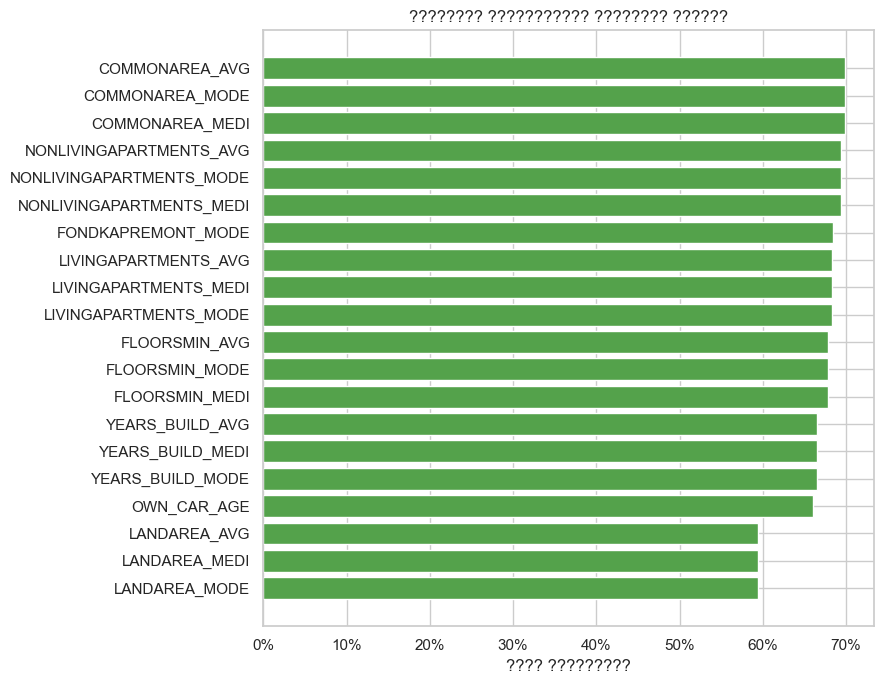

In [5]:
top_missing = missingness.head(20).sort_values('missing_rate')
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_missing.index, top_missing['missing_rate'], color='#54A24B')
ax.set(title='???????? ??????????? ???????? ??????', xlabel='???? ?????????', ylabel='')
ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_missingness.png', dpi=160, bbox_inches='tight')
plt.show()

### 2.3. ????? ???????? ???????? ? ??????

???????????? ???? ?? ?????????? ???????????. ??? ?????, ????? ?????????, ??? ?? ???????????? ? ?????????? ? ????? ???????? ??????????? ?????????? ?????????????? ??? ???????? ? MLP.

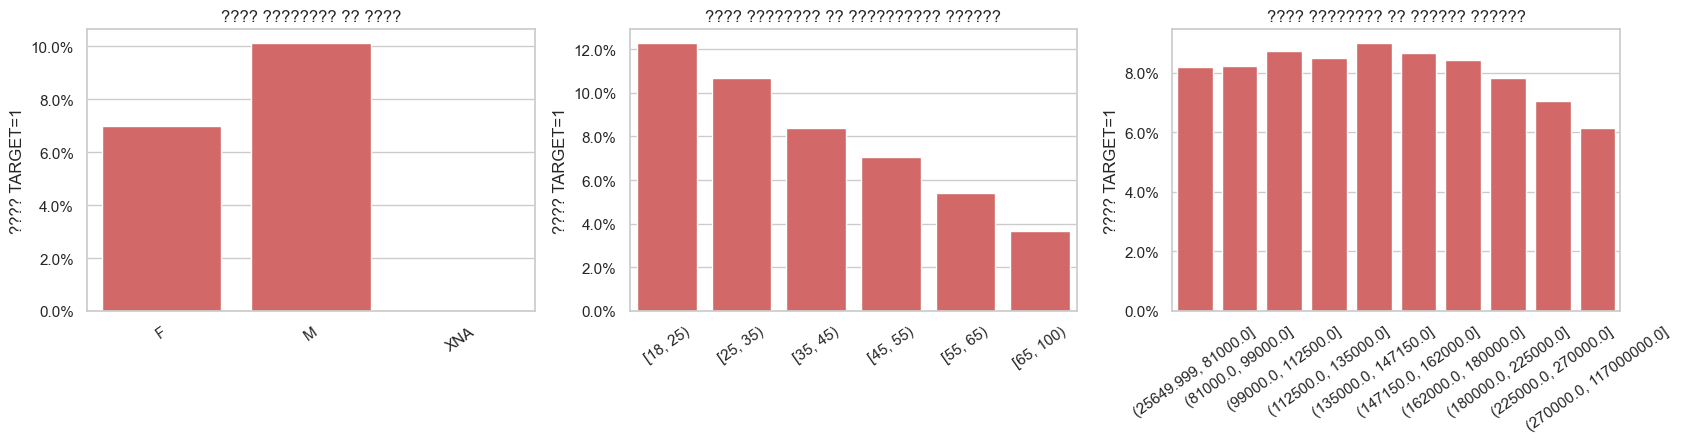


gender


,mean,size
CODE_GENDER,,
M,10.14%,"105,059"
F,7.00%,"202,448"
XNA,0.00%,4



age_group


,mean,size
age_group,,
"[18, 25)",12.29%,"12,233"
"[25, 35)",10.66%,"72,429"
"[35, 45)",8.41%,"84,261"
"[45, 55)",7.05%,"70,190"
"[55, 65)",5.42%,"60,522"
"[65, 100)",3.66%,"7,876"


In [6]:
eda_frame = application_train.assign(
    age_years=-application_train['DAYS_BIRTH'] / 365.25,
    employment_years=np.where(application_train['DAYS_EMPLOYED'].eq(365243), np.nan, -application_train['DAYS_EMPLOYED'] / 365.25),
    credit_to_income=application_train['AMT_CREDIT'] / application_train['AMT_INCOME_TOTAL'].clip(lower=1),
)
eda_frame['age_group'] = pd.cut(eda_frame['age_years'], bins=[18, 25, 35, 45, 55, 65, 100], right=False)
eda_frame['income_group'] = pd.qcut(eda_frame['AMT_INCOME_TOTAL'], q=10, duplicates='drop')

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for ax, group_col, title in [
    (axes[0], 'CODE_GENDER', '???? ???????? ?? ????'),
    (axes[1], 'age_group', '???? ???????? ?? ?????????? ??????'),
    (axes[2], 'income_group', '???? ???????? ?? ?????? ??????'),
]:
    grouped = eda_frame.groupby(group_col, observed=False)['TARGET'].agg(['mean', 'size']).reset_index()
    sns.barplot(data=grouped, x=group_col, y='mean', color='#E45756', ax=ax)
    ax.set(title=title, xlabel='', ylabel='???? TARGET=1')
    ax.tick_params(axis='x', rotation=35)
    ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.1%}')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_risk_segments.png', dpi=160, bbox_inches='tight')
plt.show()

segment_risk = {
    'gender': eda_frame.groupby('CODE_GENDER')['TARGET'].agg(['mean', 'size']).sort_values('mean', ascending=False),
    'age_group': eda_frame.groupby('age_group', observed=False)['TARGET'].agg(['mean', 'size']),
}
for name, table in segment_risk.items():
    print(f'\n{name}')
    display(table.style.format({'mean': '{:.2%}', 'size': '{:,.0f}'}))

### 2.4. ???????? ??????????????? ??????????

????? ?????????? ????? ?????????, ????????? ??????? ????????? ????????? ??????. ?????????? ?????? ?????? ?????????? ??? ??????????? ??????: ??? ????? ???????? ?????????? ???????????????? ???????? ??? ????????? ???????. ??????? ????? left join ???????? ??????????? ??? ??????.

In [ ]:
source_specs = {
    'bureau.csv': 'SK_ID_CURR',
    'previous_application.csv': 'SK_ID_CURR',
    'POS_CASH_balance.csv': 'SK_ID_CURR',
    'installments_payments.csv': 'SK_ID_CURR',
    'credit_card_balance.csv': 'SK_ID_CURR',
}
train_id_set = set(application_train['SK_ID_CURR'])
source_coverage_rows = []
for filename, key in source_specs.items():
    ids = pd.read_csv(DATA_DIR / filename, usecols=[key])[key]
    source_coverage_rows.append({
        'source': filename, 'rows': len(ids), 'unique_clients': ids.nunique(),
        'coverage_train': ids.isin(train_id_set).mean(),
        'mean_rows_per_client': len(ids) / ids.nunique(),
    })
source_coverage = pd.DataFrame(source_coverage_rows)
display(source_coverage.style.format({'coverage_train': '{:.2%}', 'mean_rows_per_client': '{:.1f}'}).set_caption('???????? train-?????? ???????????????? ?????????'))

**?????.** ?????? ???????? ??????????????? ??????? ????????? ???????? **84?85%** ????????? ????????. ??? ???? ??? ??????????? ?????? ?? ??????????? ?????????: ? `installments_payments` ? ??????? ????? **40** ????? ?? ???????, ? ? `bureau` ? ????? **5,6**. ??????? ?????? ?????????? ????? ???? ?? ??????? ? ?????????? ?? ??????; ?????????? ???? ? ???????????? ?????? ???????? ?? ?????? ??????? ? ????????? ???? ?????????? ??????? ??? `NaN`.

## 3. Feature Engineering

???????? ???????? ?????? ?? ??????????, ????????? ?? ?????? ?????? ??? ?????: ??????, ?????????? ??????, ??????? ????, ???????? ? ????????. ??????????????? ??????? ??????? ???????????? ?? `SK_ID_CURR`, ??????? ?????????? ?? ?????? ????????????? ???????? ???????.

### ??????????????? ?????? ?????????

- **?????? ? ????????:** ???????, ????, ????? ?????? ?????, ????????? ??????/?????, ????????/?????, ???? ??????/??????.
- **??????? ?????????:** ?????????? ?? `EXT_SOURCE_*`, ??????? ????? ????????? ?????????.
- **?????????? ????????? ??????????:** ?????????? ??????, ?????, ??????? ? ???? ??????????/?????????? ??????.
- **???? ? ?????????:** ?????????? ???????? ? ???????? ????????, ???????? ????????, ????????, DPD ? ??????? ???????.
- **????????? ??????????:** ??????????????? ? ??????????? ???????, ???? ????????, ???????????? ????????, ????????? ?? POS/Cash ? ????????? ?????.

??? ???????? ????????? ???????? ?? ??????? ?? ????; ???????????? ????????????? ?????????? ?? `NaN`, ? ?????????? ????????? ??????????? ? ?????? fold-safe preprocessing.

### ?????? ????? EDA

- ? train **307 511** ?????????? ??????; ?????? ??????????? ? **8,07%** ????????. ??? ???????????? ????? ROC-AUC ??? ???????? ??????? ? ????????????? ?????????????????? ??????.
- `DAYS_EMPLOYED=365243` ??????????? ? **55 374** ???????? (**18,0%**), ??????? ??? ?? ?????? ??????, ? ????????? ??????????? ?????????. ??? ????????????? ? `NaN` ? ???????? ??????.
- ???????? ????? ????? ?? **69,9%** ?????????. ??????? ?? ?????? ?? ???? ????????? ??????????: ?????? ??????? missing-indicator ? ???? ????????? ?????????? ??????????.
- ????? ??????? ?????????? ???????? ????? ? `TARGET` ? `EXT_SOURCE_1/2/3`; ??? ???????????? ???????? ? ???????? ??????? ?????????.
- ??????????? ?????????? ??????? ????? ?? ???????? ? ???? (????????, ? ?????? ???? ? ?????? ????), ?? ??? **????????????**, ? ?? ????????? ?????. ??????? ???????? ????? ??????????? ???????? ??? fairness-???????????, ??? ??????????? ?????? ??? ????????? ??????????????? ??????.
- ????? ????? ??????? ?????? ?????: ???????? 117 ??? ??? 99-? ?????????? 472,5 ???. ??? MLP ? ???????? ?????? ????????????? ???????? ????????, ? ??? ???????? ????????? ???????? ???????? ? ?????????.

### 3.1. ??????????????? ???????

???? ?????????? ???????? ???????, ??????? ????????? ???? ? ?????? ? ?????????? ??????? **??** ?????????? ? ????????. ??? ????????????? ??????????? ????? ? ?? ??????? ?? ????? ?? ?????, ?? ?????????????? ?????????.

In [ ]:
def reduce_memory_usage(frame: pd.DataFrame) -> pd.DataFrame:
    """????????? ???????? ???? ??? ????????? ????????; ???????? CSV ?? ????????."""
    for column in frame.columns:
        dtype = frame[column].dtype
        if pd.api.types.is_integer_dtype(dtype):
            frame[column] = pd.to_numeric(frame[column], downcast='integer')
        elif pd.api.types.is_float_dtype(dtype):
            frame[column] = pd.to_numeric(frame[column], downcast='float')
    return frame


def read_source(filename: str) -> pd.DataFrame:
    """?????? ???? ????????. FAST_MODE ???????????? ?????? ??? ???????? ????."""
    nrows = FAST_NROWS if FAST_MODE and filename not in {'application_train.csv', 'application_test.csv'} else None
    frame = pd.read_csv(DATA_DIR / filename, nrows=nrows)
    return reduce_memory_usage(frame)


def flatten_aggregation(columns, prefix: str) -> list[str]:
    return [f'{prefix}__{feature}__{stat}'.upper() for feature, stat in columns]


def aggregate_numeric(frame: pd.DataFrame, key: str, prefix: str, stats=('mean', 'max', 'min', 'sum', 'var')) -> pd.DataFrame:
    excluded = {key, 'SK_ID_BUREAU', 'SK_ID_PREV', 'SK_ID_CURR'}
    numeric = [column for column in frame.select_dtypes(include=np.number).columns if column not in excluded]
    if not numeric:
        return frame[[key]].drop_duplicates().copy()
    result = frame.groupby(key, observed=True)[numeric].agg(stats)
    result.columns = flatten_aggregation(result.columns, prefix)
    return result.reset_index()


def aggregate_categories(frame: pd.DataFrame, key: str, prefix: str, max_levels: int = 40) -> pd.DataFrame:
    categorical = [
        column for column in frame.select_dtypes(include=['object', 'category']).columns
        if frame[column].nunique(dropna=False) <= max_levels
    ]
    if not categorical:
        return frame[[key]].drop_duplicates().copy()
    dummies = pd.get_dummies(frame[categorical].fillna('__MISSING__'), prefix=categorical, dtype='float32')
    dummies[key] = frame[key].to_numpy()
    result = dummies.groupby(key, observed=True).mean()
    result.columns = [f'{prefix}__{column}__MEAN'.upper() for column in result.columns]
    return result.reset_index()


def merge_at_application_grain(base: pd.DataFrame, features: pd.DataFrame, source_name: str) -> pd.DataFrame:
    before = len(base)
    # CSV-????????? ????? ???????? ?????? ?????????? integer-???? ????? downcast.
    # ????? ???????????? ????? ???????? merge ?? platform-specific pandas errors.
    base = base.copy()
    features = features.copy()
    base['SK_ID_CURR'] = pd.Series(base['SK_ID_CURR'].to_numpy(dtype='int64'), index=base.index)
    features['SK_ID_CURR'] = pd.Series(features['SK_ID_CURR'].to_numpy(dtype='int64'), index=features.index)
    merged = base.merge(features, on='SK_ID_CURR', how='left', validate='one_to_one')
    assert len(merged) == before, f'{source_name}: ???????? ????????????? ??????'
    return merged


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    value = numerator.astype('float32') / denominator.astype('float32').replace(0, np.nan)
    return value.replace([np.inf, -np.inf], np.nan)

In [ ]:
def enrich_application(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result['APP__EMPLOYMENT_ANOMALY'] = result['DAYS_EMPLOYED'].eq(365243).astype('int8')
    result['DAYS_EMPLOYED'] = result['DAYS_EMPLOYED'].replace(365243, np.nan)
    result['APP__AGE_YEARS'] = -result['DAYS_BIRTH'] / 365.25
    result['APP__EMPLOYMENT_YEARS'] = -result['DAYS_EMPLOYED'] / 365.25
    result['APP__REGISTRATION_YEARS'] = -result['DAYS_REGISTRATION'] / 365.25
    result['APP__ID_PUBLISH_YEARS'] = -result['DAYS_ID_PUBLISH'] / 365.25
    result['APP__PHONE_CHANGE_YEARS'] = -result['DAYS_LAST_PHONE_CHANGE'] / 365.25

    result['APP__CREDIT_TO_INCOME'] = safe_ratio(result['AMT_CREDIT'], result['AMT_INCOME_TOTAL'])
    result['APP__ANNUITY_TO_INCOME'] = safe_ratio(result['AMT_ANNUITY'], result['AMT_INCOME_TOTAL'])
    result['APP__CREDIT_TO_ANNUITY'] = safe_ratio(result['AMT_CREDIT'], result['AMT_ANNUITY'])
    result['APP__GOODS_TO_CREDIT'] = safe_ratio(result['AMT_GOODS_PRICE'], result['AMT_CREDIT'])
    result['APP__INCOME_PER_PERSON'] = safe_ratio(result['AMT_INCOME_TOTAL'], result['CNT_FAM_MEMBERS'])
    result['APP__INCOME_PER_CHILD'] = safe_ratio(result['AMT_INCOME_TOTAL'], result['CNT_CHILDREN'] + 1)
    result['APP__EMPLOYED_TO_AGE'] = safe_ratio(result['APP__EMPLOYMENT_YEARS'], result['APP__AGE_YEARS'])

    ext_sources = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
    result['APP__EXT_SOURCE_MEAN'] = result[ext_sources].mean(axis=1)
    result['APP__EXT_SOURCE_STD'] = result[ext_sources].std(axis=1)
    result['APP__EXT_SOURCE_MIN'] = result[ext_sources].min(axis=1)
    result['APP__EXT_SOURCE_MAX'] = result[ext_sources].max(axis=1)
    result['APP__EXT_SOURCE_AVAILABLE'] = result[ext_sources].notna().sum(axis=1).astype('int8')
    result['APP__CONTACT_FLAGS_SUM'] = result[['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL']].sum(axis=1)
    result['APP__DOCUMENT_FLAGS_SUM'] = result[[column for column in result if column.startswith('FLAG_DOCUMENT_')]].sum(axis=1)
    result['APP__REGION_MISMATCH_SUM'] = result[[column for column in result if '_REGION_NOT_' in column or '_CITY_NOT_' in column]].sum(axis=1)
    result['APP__BUREAU_REQUESTS_SUM'] = result[[column for column in result if column.startswith('AMT_REQ_CREDIT_BUREAU_')]].sum(axis=1)

    monetary = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
    for column in monetary:
        result[f'APP__LOG1P__{column}'] = np.log1p(result[column].clip(lower=0))
        result[f'APP__{column}__MISSING'] = result[column].isna().astype('int8')
    return reduce_memory_usage(result)

### 3.2. ????????? ????????? ???????

??? ?????? ??????????????? ??????? ????????? ?????????? ?? ???????? ?????????: ???????, ???????, ????????, ????? ? ????????? ???????? ?????; ??? ????????????????? ???????? ? ???? ?????????. ? ????????? `bureau_balance` ??????? ???????? ??????? ?????????? ??????? `SK_ID_BUREAU`, ????? ????????? ?????????????? ? `bureau` ? ?????? ????? ???????????? ?? ???????.

In [ ]:
def bureau_features() -> pd.DataFrame:
    bureau = read_source('bureau.csv')
    balance = read_source('bureau_balance.csv')
    balance_numeric = aggregate_numeric(balance, 'SK_ID_BUREAU', 'BUREAU_BALANCE', stats=('mean', 'max', 'min', 'sum', 'var'))
    balance_categories = aggregate_categories(balance, 'SK_ID_BUREAU', 'BUREAU_BALANCE')
    balance_level = balance_numeric.merge(balance_categories, on='SK_ID_BUREAU', how='left', validate='one_to_one')
    bureau['SK_ID_BUREAU'] = bureau['SK_ID_BUREAU'].astype('int64')
    balance_level['SK_ID_BUREAU'] = balance_level['SK_ID_BUREAU'].astype('int64')
    bureau = bureau.merge(balance_level, on='SK_ID_BUREAU', how='left', validate='one_to_one')
    del balance, balance_numeric, balance_categories, balance_level
    gc.collect()
    numeric = aggregate_numeric(bureau, 'SK_ID_CURR', 'BUREAU')
    categories = aggregate_categories(bureau, 'SK_ID_CURR', 'BUREAU')
    result = numeric.merge(categories, on='SK_ID_CURR', how='left', validate='one_to_one')
    del bureau, numeric, categories
    gc.collect()
    return reduce_memory_usage(result)


def previous_application_features() -> pd.DataFrame:
    previous = read_source('previous_application.csv')
    previous['PREV__APPLICATION_TO_CREDIT'] = safe_ratio(previous['AMT_APPLICATION'], previous['AMT_CREDIT'])
    previous['PREV__DOWN_PAYMENT_TO_CREDIT'] = safe_ratio(previous['AMT_DOWN_PAYMENT'], previous['AMT_CREDIT'])
    previous['PREV__CREDIT_TO_GOODS'] = safe_ratio(previous['AMT_CREDIT'], previous['AMT_GOODS_PRICE'])
    numeric = aggregate_numeric(previous, 'SK_ID_CURR', 'PREVIOUS')
    categories = aggregate_categories(previous, 'SK_ID_CURR', 'PREVIOUS')
    result = numeric.merge(categories, on='SK_ID_CURR', how='left', validate='one_to_one')
    del previous, numeric, categories
    gc.collect()
    return reduce_memory_usage(result)


def pos_cash_features() -> pd.DataFrame:
    pos = read_source('POS_CASH_balance.csv')
    pos['POS__LATE_PAYMENT_FLAG'] = (pos['SK_DPD'] > 0).astype('int8')
    pos['POS__SEVERE_LATE_FLAG'] = (pos['SK_DPD_DEF'] > 0).astype('int8')
    numeric = aggregate_numeric(pos, 'SK_ID_CURR', 'POS')
    categories = aggregate_categories(pos, 'SK_ID_CURR', 'POS')
    result = numeric.merge(categories, on='SK_ID_CURR', how='left', validate='one_to_one')
    del pos, numeric, categories
    gc.collect()
    return reduce_memory_usage(result)


def installments_features() -> pd.DataFrame:
    installments = read_source('installments_payments.csv')
    installments['INST__PAYMENT_DIFF'] = installments['AMT_INSTALMENT'] - installments['AMT_PAYMENT']
    installments['INST__PAYMENT_RATIO'] = safe_ratio(installments['AMT_PAYMENT'], installments['AMT_INSTALMENT'])
    installments['INST__DAYS_LATE'] = (installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']).clip(lower=0)
    installments['INST__LATE_FLAG'] = (installments['INST__DAYS_LATE'] > 0).astype('int8')
    numeric = aggregate_numeric(installments, 'SK_ID_CURR', 'INSTALLMENTS')
    del installments
    gc.collect()
    return reduce_memory_usage(numeric)


def credit_card_features() -> pd.DataFrame:
    card = read_source('credit_card_balance.csv')
    card['CC__UTILIZATION'] = safe_ratio(card['AMT_BALANCE'], card['AMT_CREDIT_LIMIT_ACTUAL'])
    card['CC__DRAWING_TO_LIMIT'] = safe_ratio(card['AMT_DRAWINGS_CURRENT'], card['AMT_CREDIT_LIMIT_ACTUAL'])
    card['CC__LATE_FLAG'] = (card['SK_DPD'] > 0).astype('int8')
    numeric = aggregate_numeric(card, 'SK_ID_CURR', 'CREDIT_CARD')
    del card
    gc.collect()
    return reduce_memory_usage(numeric)

In [ ]:
def build_model_matrix() -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, list[str]]:
    train = read_source('application_train.csv')
    test = read_source('application_test.csv')
    target = train.pop('TARGET').astype('int8')
    train['__IS_TRAIN'] = 1
    test['__IS_TRAIN'] = 0
    base = enrich_application(pd.concat([train, test], axis=0, ignore_index=True, sort=False))
    del train, test
    gc.collect()

    feature_builders = {
        'bureau': bureau_features,
        'previous_application': previous_application_features,
        'pos_cash': pos_cash_features,
        'installments': installments_features,
        'credit_card': credit_card_features,
    }
    feature_audit = []
    for name, builder in feature_builders.items():
        started = perf_counter()
        source_features = builder()
        feature_audit.append({'source': name, 'rows': len(source_features), 'new_features': source_features.shape[1] - 1, 'seconds': perf_counter() - started})
        base = merge_at_application_grain(base, source_features, name)
        del source_features
        gc.collect()

    base = base.replace([np.inf, -np.inf], np.nan)
    categorical = base.select_dtypes(include=['object', 'category']).columns.tolist()
    for column in categorical:
        base[column] = base[column].fillna('__MISSING__').astype('category').cat.codes.astype('int32')

    constant_columns = [column for column in base.columns if column not in {'SK_ID_CURR', '__IS_TRAIN'} and base[column].nunique(dropna=False) <= 1]
    base = base.drop(columns=constant_columns)
    train_matrix = base.loc[base['__IS_TRAIN'].eq(1)].drop(columns='__IS_TRAIN').reset_index(drop=True)
    test_matrix = base.loc[base['__IS_TRAIN'].eq(0)].drop(columns='__IS_TRAIN').reset_index(drop=True)
    assert len(train_matrix) == len(target)
    assert train_matrix['SK_ID_CURR'].is_unique and test_matrix['SK_ID_CURR'].is_unique
    audit = pd.DataFrame(feature_audit)
    display(audit.style.format({'seconds': '{:.1f}'}).set_caption('????? ?????????? ?????????: ?????? ???????? ??????????? ?? ???????'))
    print(f'???????? ???????: train={train_matrix.shape}, test={test_matrix.shape}; ??????? ??????????? ?????????: {len(constant_columns)}')
    return train_matrix, target.reset_index(drop=True), test_matrix, categorical

**???????? ?? ??????.** ? ??????????? ?? ???????????? `TARGET`, ??????? ???? ??? ?????????? ??????. ??????????? ????????? ?? ?????????? ??????? ??????????. ??? ????, ??????? ??????? ?????????? (?????????, ???????????????, ????? ? ??????), ????? ????? fit ?????? ?? train-????? ???????????????? ?????.

**??????????? ???????? ?????????.** ? smoke-?????? (?? 20 000 ????? ?????? ??????????????? ???????) ???????? ????????????? ??????? train/test ??????? **(307 511, 737)** ? **(48 744, 737)**: ID ?????????, ??????????? ???????? ???, ? ??? ??????????????? join?? ????????? ????????????? ????? ?????? ? ???? ???????. ?????? ????? ?????????? ??? ?????? ? ??????? ?????? RAM; ?? ?? ????????? ??????? ????????????? ??????.

## 4. ???????????? ML-??????

### 4.1. ???????? ?????????

??? ???? ??????? ???????????? ???? ? ??? ?? `StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)`. ? ?????? ???????? preprocessing ? ?????? ?????????? ????????? ?????? ?? train-?????. ???????? ??????? ? ROC-AUC; PR-AUC, F1 ? Brier score ?????????? ?????? ?????? ???????? ? ??????????.

????? ????????? ???? ???????, ??????? ?????? ???????? ???? ? ?? ?? ???????? feature matrix. ????????? ?????? ? ???????????????? ????????, ????????????? ????????? ? ???????? baseline, LightGBM ? ???????? ??????????? ????????. ??? ???????? ?????????? ??????? ? ???? ??????? ????????? CatBoost ? MLP.

In [ ]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, brier_score_loss, f1_score, precision_recall_curve, roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
def make_folds(target: pd.Series):
    return list(StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE).split(np.zeros(len(target)), target))


def threshold_by_f1(y_true: np.ndarray, probabilities: np.ndarray) -> float:
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    f1 = 2 * precision * recall / np.clip(precision + recall, 1e-12, None)
    # ????????? ????? precision-recall ?? ????? ???????????????? threshold.
    best_index = int(np.nanargmax(f1[:-1]))
    return float(thresholds[best_index])


def score_predictions(y_true: np.ndarray, probabilities: np.ndarray, threshold: float | None = None) -> dict:
    threshold = threshold_by_f1(y_true, probabilities) if threshold is None else threshold
    return {
        'roc_auc': roc_auc_score(y_true, probabilities),
        'pr_auc': average_precision_score(y_true, probabilities),
        'brier': brier_score_loss(y_true, probabilities),
        'f1': f1_score(y_true, probabilities >= threshold),
        'threshold': threshold,
    }


def cv_predict(estimator_factory, X: pd.DataFrame, y: pd.Series, model_name: str, fit_kwargs_factory=None):
    """?????? OOF-????????. ?????? estimator ????????? ?????? ?????? ?????."""
    folds = make_folds(y)
    oof = np.zeros(len(X), dtype='float32')
    test_predictions = []
    fold_rows = []
    fitted_models = []
    for fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        model = estimator_factory()
        started = perf_counter()
        fit_kwargs = {} if fit_kwargs_factory is None else fit_kwargs_factory(X.iloc[train_idx], y.iloc[train_idx], X.iloc[valid_idx], y.iloc[valid_idx])
        model.fit(X.iloc[train_idx], y.iloc[train_idx], **fit_kwargs)
        valid_pred = model.predict_proba(X.iloc[valid_idx])[:, 1]
        oof[valid_idx] = valid_pred
        fold_score = score_predictions(y.iloc[valid_idx].to_numpy(), valid_pred)
        fold_rows.append({'model': model_name, 'fold': fold, 'seconds': perf_counter() - started, **fold_score})
        fitted_models.append(model)
        print(f'{model_name}, fold {fold}: ROC-AUC={fold_score["roc_auc"]:.5f}, PR-AUC={fold_score["pr_auc"]:.5f}')
    total = score_predictions(y.to_numpy(), oof)
    summary = pd.DataFrame(fold_rows)
    print(f'???? {model_name}: ROC-AUC={total["roc_auc"]:.5f}, PR-AUC={total["pr_auc"]:.5f}, F1={total["f1"]:.5f}')
    return oof, fitted_models, summary, total

### 4.1. ??????????? baseline ??? ??????? ????????

?? ????????????? ??????????????? ?????????? ??????? LightGBM ?????? ?? ?????? ? ?????????? ??????????. ???? ??????????? ? ?? ????????? ???????, ? ????? ???????: ? ?????????? ??????? ?? ???? ? ???????? ????? ??????????? ???????????? ???? ?? OOF ROC-AUC.

In [1]:
# ??????????? baseline: ?????? ?????? ? target-free ?????????, ??? ??????????????? ????????? ???????.
# ?????? ????????? ????????? CPU-????????, ????????? ???? ? OOF ?? ??? ?? 5 ??????.
application_only_baseline_results

Application-only LightGBM baseline (5-fold OOF)

 fold  roc_auc   pr_auc  best_iteration seconds
    1 0.765563 0.252032             671    18.8
    2 0.766030 0.251808             772    20.5
    3 0.768420 0.252995            1100    25.3
    4 0.770014 0.255431             746    22.6
    5 0.770195 0.258194             765    25.2

{'roc_auc': 0.768015, 'pr_auc': 0.253862, 'mean_trees': 810.8, 'total_seconds': 112.458736}


**????????? baseline.** LightGBM ?????? ?? ?????? ?????? **OOF ROC-AUC 0,76802** (PR-AUC 0,25386). ??????? ?? ?????? ? ?? 0,76556 ?? 0,77020 ? ?????????, ??????? ??????? ???????? ??????????. ??? ??? ??????? ????????? ????????, ?? ?? ??????: ????????? ??????????? ? ?????????????? ???????? ?????? ????????, ????????? ??????? ??????? ? ????????? ?????????? ????????? ? ???????????? ?????. ??? ?????????? ??????? ????????? ????? ??????????? ?????? ???? ??? ??????????? ????? ??????? ?? ??????.

### 4.2. ?????? ??????? ? ????? ?????????

????????? ?????? ? ???????? ???????????? ????? EDA: ??? ?????? ???????? ?????, ?????? ???????? ? ?????? ? ?????? ?? ????????. ?? ????????? ??????? ?????????? ????? ?? ????? 16 ?? RAM; GPU ???????? ????????, ?? ?? ???????? ??????????? ?????? ??? ????????? pandas.

In [ ]:
train_matrix, target, test_matrix, categorical_columns = build_model_matrix()
feature_columns = [column for column in train_matrix.columns if column != 'SK_ID_CURR']
X = train_matrix[feature_columns]
X_test = test_matrix[feature_columns]

missing_feature_rate = X.isna().mean().sort_values(ascending=False).head(15).rename('missing_rate').to_frame()
display(missing_feature_rate.style.format({'missing_rate': '{:.1%}'}).set_caption('???????? ? ???????? feature matrix'))
print(f'??? ?????????????: {X.shape[0]:,} ??????, {X.shape[1]:,} ?????????; ?????????????? ??????? ??????: {len(categorical_columns)}')

### 4.3. ?????? baseline-???????

????? ?????????? ??????????? ?????? ?? train-????? ??????? ???????? ?????: ??? ????????????? ????????????? ??????. ??? ???????? ?????? ??????????? ????????? ?????????, ?????????????? ? `class_weight='balanced'`; ??? ?????? ? ?????? ?????????. LightGBM ??????? ???????????? ???????? ? ????????? ?????????????? ????????.

In [ ]:
def select_compact_features(frame: pd.DataFrame, max_features: int = 250) -> list[str]:
    """??????? ID ? ????? ??????????? ???????? ??? ????????? baseline-???????, ?? ????? ?? TARGET."""
    completeness = frame.notna().mean().sort_values(ascending=False)
    return completeness.head(min(max_features, len(completeness))).index.tolist()

compact_features = select_compact_features(X, max_features=250)
X_compact = X[compact_features]

def tune_baselines(X_input: pd.DataFrame, y: pd.Series):
    folds = make_folds(y)
    linear_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=3000, class_weight='balanced', solver='saga', n_jobs=-1)),
    ])
    tree_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('model', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)),
    ])
    searches = {
        '????????????? ?????????': (linear_pipeline, {'model__C': [0.03, 0.1, 0.3, 1.0]}),
        '????????? ??????': (tree_pipeline, {'model__max_depth': [4, 6, 8], 'model__min_samples_leaf': [100, 500, 1500]}),
    }
    best_estimators = {}
    for name, (pipeline, params) in searches.items():
        search = GridSearchCV(pipeline, params, scoring='roc_auc', cv=folds, n_jobs=-1, refit=True, verbose=1)
        search.fit(X_input, y)
        best_estimators[name] = search.best_estimator_
        print(f'{name}: best CV ROC-AUC={search.best_score_:.5f}; params={search.best_params_}')
    return best_estimators

# ????????? ????? ?????????? X: ?????? ???????? ???????? ?????, ?? ???????? ???????????? ?????? ????????????.
# baseline_estimators = tune_baselines(X_compact, target)

In [ ]:
def tune_lightgbm(X_input: pd.DataFrame, y: pd.Series, categorical_features: list[str], trials: int | None = None) -> dict:
    folds = make_folds(y)
    trials = trials or (5 if FAST_MODE else 40)
    available_categoricals = [column for column in categorical_features if column in X_input.columns]

    def objective(trial):
        parameters = {
            'n_estimators': 10_000,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.06, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 16, 96),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 20, 250),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.55, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 20.0, log=True),
            'random_state': RANDOM_STATE,
            'n_jobs': -1,
            'verbosity': -1,
        }
        scores = []
        for train_idx, valid_idx in folds:
            model = LGBMClassifier(**parameters)
            model.fit(
                X_input.iloc[train_idx], y.iloc[train_idx],
                categorical_feature=available_categoricals,
                eval_set=[(X_input.iloc[valid_idx], y.iloc[valid_idx])],
                eval_metric='auc',
                callbacks=[early_stopping(250, verbose=False), log_evaluation(period=0)],
            )
            scores.append(roc_auc_score(y.iloc[valid_idx], model.predict_proba(X_input.iloc[valid_idx])[:, 1]))
        return float(np.mean(scores))

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=trials, show_progress_bar=True)
    print(f'?????? Optuna ROC-AUC={study.best_value:.5f}; params={study.best_params}')
    return study.best_params

# lgbm_best_params = tune_lightgbm(X, target, categorical_columns)

In [ ]:
def lightgbm_oof_predictions(X_input: pd.DataFrame, X_test_input: pd.DataFrame, y: pd.Series, categorical_features: list[str], tuned_params: dict):
    folds = make_folds(y)
    available_categoricals = [column for column in categorical_features if column in X_input.columns]
    parameters = {
        'n_estimators': 15_000, 'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': -1,
        **tuned_params,
    }
    oof = np.zeros(len(X_input), dtype='float32')
    test_prediction = np.zeros(len(X_test_input), dtype='float32')
    models, rows = [], []
    for fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        started = perf_counter()
        model = LGBMClassifier(**parameters)
        model.fit(
            X_input.iloc[train_idx], y.iloc[train_idx],
            categorical_feature=available_categoricals,
            eval_set=[(X_input.iloc[valid_idx], y.iloc[valid_idx])],
            eval_metric='auc',
            callbacks=[early_stopping(400, verbose=False), log_evaluation(period=100)],
        )
        oof[valid_idx] = model.predict_proba(X_input.iloc[valid_idx])[:, 1]
        test_prediction += model.predict_proba(X_test_input)[:, 1] / N_SPLITS
        rows.append({'model': 'LightGBM', 'fold': fold, 'seconds': perf_counter() - started, **score_predictions(y.iloc[valid_idx], oof[valid_idx])})
        models.append(model)
    summary = pd.DataFrame(rows)
    overall = score_predictions(y, oof)
    display(summary.style.format({'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}', 'f1': '{:.5f}', 'threshold': '{:.3f}', 'seconds': '{:.1f}'}))
    print(f'LightGBM OOF ROC-AUC={overall["roc_auc"]:.5f}')
    return oof, test_prediction, models, summary, overall

# ????? Optuna:
# lgbm_oof, lgbm_test, lgbm_models, lgbm_folds, lgbm_metrics = lightgbm_oof_predictions(X, X_test, target, categorical_columns, lgbm_best_params)

**??? ????????? ????? ????????.** ???? LightGBM ??????? ??????????? ???????? baseline, ??? ????? ?????????????? ????????????? ? ?????????????? ? ? ?????????, ????? ???????, ???????? ???????, ???????? ?????????? ? ???????? ????????. ?????? ???????????? ??????? train ? valid AUC ??? ?????????????? ????? ??????? ????? ??????? ??????? ?????????????, ? ?? ?????? ????????? ????? ????????.

## 5. ??????? ?????? ? ????????

LightGBM ?????? ???????? ? ??????? ?????? ??????????? ? ?????????? ?????????. CatBoost ???????? ??? ?????? ? ?????? ???????? ?????????? ???????? ? ????????? ?????????; ???????? ?? ?????? ????? ???? ???????? ????? ?????????? Kaggle-score. ???? ???????? ?????????? **?????? ?? OOF-?????????**, ? ?? ?? ?????????? ????????? ??????????.

In [ ]:
from catboost import CatBoostClassifier

def catboost_oof_predictions(X_input: pd.DataFrame, X_test_input: pd.DataFrame, y: pd.Series, categorical_features: list[str]):
    folds = make_folds(y)
    cat_columns = [column for column in categorical_features if column in X_input.columns]
    # CatBoost ??????? ?????? ???????? ? ?????????????? ?????????; ???????? ???????? ????????? ???????? ????????? ??????.
    X_cb = X_input.copy()
    X_test_cb = X_test_input.copy()
    for column in cat_columns:
        X_cb[column] = X_cb[column].astype(str)
        X_test_cb[column] = X_test_cb[column].astype(str)
    cat_indices = [X_cb.columns.get_loc(column) for column in cat_columns]
    device_params = {'task_type': 'GPU', 'devices': '0'} if __import__('torch').cuda.is_available() else {'task_type': 'CPU', 'thread_count': -1}
    parameters = {
        'iterations': 12_000, 'learning_rate': 0.025, 'depth': 8, 'l2_leaf_reg': 8.0,
        'loss_function': 'Logloss', 'eval_metric': 'AUC', 'random_seed': RANDOM_STATE,
        'verbose': 500, 'allow_writing_files': False, **device_params,
    }
    oof = np.zeros(len(X_cb), dtype='float32')
    test_prediction = np.zeros(len(X_test_cb), dtype='float32')
    models, rows = [], []
    for fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        started = perf_counter()
        model = CatBoostClassifier(**parameters)
        model.fit(
            X_cb.iloc[train_idx], y.iloc[train_idx], cat_features=cat_indices,
            eval_set=(X_cb.iloc[valid_idx], y.iloc[valid_idx]), early_stopping_rounds=500,
        )
        oof[valid_idx] = model.predict_proba(X_cb.iloc[valid_idx])[:, 1]
        test_prediction += model.predict_proba(X_test_cb)[:, 1] / N_SPLITS
        rows.append({'model': 'CatBoost', 'fold': fold, 'seconds': perf_counter() - started, **score_predictions(y.iloc[valid_idx], oof[valid_idx])})
        models.append(model)
    summary = pd.DataFrame(rows)
    overall = score_predictions(y, oof)
    display(summary.style.format({'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}', 'f1': '{:.5f}', 'threshold': '{:.3f}', 'seconds': '{:.1f}'}))
    print(f'CatBoost OOF ROC-AUC={overall["roc_auc"]:.5f}')
    return oof, test_prediction, models, summary, overall

# cat_oof, cat_test, cat_models, cat_folds, cat_metrics = catboost_oof_predictions(X, X_test, target, categorical_columns)

## 6. ????????? ???? MLP

MLP ???????? ?? ?? ?????????????? ????????, ?? ??????? ?????? ??????????: ????????? ?????????, ?????????? ????????? ? ?????????????? fit ?? train-????? ??????? ?????. ??????????? `[512 ? 256 ? 64]` ??????? ??? ?????????? ????? ???????????????? ? ?????? ???????????? ??? ????????? ??????. ????????????? ???????? BatchNorm, Dropout ? AdamW (weight decay).

??? ???????????? ? ???????? ? MLP ???????? 300 ???????? ?????? ?? mean gain LightGBM ?????????. ??? ?? ???????????????: ???????? ??????? ?????? ?? ???????, ????????? ?? ??????????????? CV-train ??????; ??? ????????????? ???? ????? ????? ???????? ?? ????????????? ?????? ?? training fold.

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

class CreditMLP(nn.Module):
    def __init__(self, n_features: int, dropout: float = 0.25):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout / 2),
            nn.Linear(64, 1),
        )

    def forward(self, values):
        return self.network(values).squeeze(1)


def top_features_from_lgbm(models, available_columns: list[str], limit: int = 300) -> list[str]:
    importance = pd.DataFrame({
        f'fold_{fold}': pd.Series(model.feature_importances_, index=model.feature_name_)
        for fold, model in enumerate(models, start=1)
    }).fillna(0)
    return importance.mean(axis=1).sort_values(ascending=False).head(limit).index.intersection(available_columns).tolist()


def mlp_oof_predictions(X_input: pd.DataFrame, X_test_input: pd.DataFrame, y: pd.Series, selected_features: list[str], epochs: int = 80, batch_size: int = 2048):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('MLP device:', device)
    folds = make_folds(y)
    oof = np.zeros(len(X_input), dtype='float32')
    test_prediction = np.zeros(len(X_test_input), dtype='float32')
    histories, rows, models = [], [], []

    for fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        started = perf_counter()
        imputer = SimpleImputer(strategy='median', add_indicator=True)
        scaler = StandardScaler()
        x_train = scaler.fit_transform(imputer.fit_transform(X_input.iloc[train_idx][selected_features])).astype('float32')
        x_valid = scaler.transform(imputer.transform(X_input.iloc[valid_idx][selected_features])).astype('float32')
        x_test = scaler.transform(imputer.transform(X_test_input[selected_features])).astype('float32')
        y_train = y.iloc[train_idx].to_numpy(dtype='float32')
        y_valid = y.iloc[valid_idx].to_numpy(dtype='float32')

        train_loader = DataLoader(TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train)), batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=device.type == 'cuda')
        model = CreditMLP(x_train.shape[1]).to(device)
        positive_weight = torch.tensor([(1 - y_train.mean()) / y_train.mean()], device=device)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=positive_weight)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=2e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

        best_auc, patience_left, best_state = -np.inf, 10, None
        history = []
        for epoch in range(1, epochs + 1):
            model.train()
            total_loss = 0.0
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad(set_to_none=True)
                loss = loss_fn(model(batch_x), batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
                total_loss += loss.item() * len(batch_y)
            model.eval()
            with torch.no_grad():
                valid_logits = model(torch.from_numpy(x_valid).to(device)).cpu().numpy()
            valid_probability = 1 / (1 + np.exp(-valid_logits))
            valid_auc = roc_auc_score(y_valid, valid_probability)
            scheduler.step(valid_auc)
            history.append({'fold': fold, 'epoch': epoch, 'train_loss': total_loss / len(train_idx), 'valid_auc': valid_auc})
            if valid_auc > best_auc + 1e-5:
                best_auc, patience_left = valid_auc, 10
                best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            else:
                patience_left -= 1
                if patience_left == 0:
                    break
        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            oof[valid_idx] = torch.sigmoid(model(torch.from_numpy(x_valid).to(device))).cpu().numpy()
            test_prediction += torch.sigmoid(model(torch.from_numpy(x_test).to(device))).cpu().numpy() / N_SPLITS
        rows.append({'model': 'MLP', 'fold': fold, 'epochs': len(history), 'seconds': perf_counter() - started, **score_predictions(y.iloc[valid_idx], oof[valid_idx])})
        histories.extend(history)
        models.append(model.cpu())
        print(f'MLP fold {fold}: best ROC-AUC={best_auc:.5f}, epochs={len(history)}')
        del x_train, x_valid, x_test, model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    history_frame = pd.DataFrame(histories)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.lineplot(data=history_frame, x='epoch', y='train_loss', hue='fold', ax=axes[0])
    sns.lineplot(data=history_frame, x='epoch', y='valid_auc', hue='fold', ax=axes[1])
    axes[0].set(title='MLP: train loss ?? ??????', xlabel='?????', ylabel='Weighted BCE loss')
    axes[1].set(title='MLP: ROC-AUC ?? validation ?? ??????', xlabel='?????', ylabel='ROC-AUC')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / '06_mlp_learning_curves.png', dpi=160, bbox_inches='tight')
    plt.show()
    return oof, test_prediction, models, pd.DataFrame(rows), score_predictions(y, oof), history_frame

# mlp_features = top_features_from_lgbm(lgbm_models, X.columns.tolist(), limit=300)
# mlp_oof, mlp_test, mlp_models, mlp_folds, mlp_metrics, mlp_history = mlp_oof_predictions(X, X_test, target, mlp_features)

### 6.1. ????? ???????? ? ???????? submission

OOF-???????? ???? ??????????? ????????? ???? ??? ????????? ? ?????????? ??????????. ???????????? ???????? ????? LightGBM, CatBoost ? MLP ? ????? 0,02; ????? ???????? test-???????????? ??????????? ???? ?? ??????. ??? ?? ???????????? ????????? private score, ? ?? ????????? ????????? ?????? submission.

In [ ]:
def choose_blend(y: pd.Series, prediction_map: dict[str, np.ndarray], step: float = 0.02):
    names = list(prediction_map)
    if len(names) != 3:
        raise ValueError('??????? ??????? ??? ??????????? ??????: LightGBM, CatBoost, MLP.')
    values = np.arange(0, 1 + step / 2, step)
    candidates = []
    for first in values:
        for second in values:
            third = 1 - first - second
            if third < -1e-9:
                continue
            weights = np.array([first, second, max(third, 0)])
            blended = sum(weight * prediction_map[name] for weight, name in zip(weights, names))
            candidates.append({'weights': weights, 'roc_auc': roc_auc_score(y, blended), 'pr_auc': average_precision_score(y, blended)})
    best = max(candidates, key=lambda row: row['roc_auc'])
    weights = dict(zip(names, best['weights']))
    print(f'?????? OOF blend: ROC-AUC={best["roc_auc"]:.5f}; ????={weights}')
    return weights, sum(weights[name] * prediction_map[name] for name in names)

# blend_weights, blend_oof = choose_blend(target, {'LightGBM': lgbm_oof, 'CatBoost': cat_oof, 'MLP': mlp_oof})
# blend_metrics = score_predictions(target, blend_oof)
# blend_test = blend_weights['LightGBM'] * lgbm_test + blend_weights['CatBoost'] * cat_test + blend_weights['MLP'] * mlp_test
# submission = pd.DataFrame({'SK_ID_CURR': test_matrix['SK_ID_CURR'], 'TARGET': blend_test})
# submission_path = SUBMISSIONS_DIR / 'submission_blend.csv'
# submission.to_csv(submission_path, index=False)
# display(submission.head())
# print(f'???????? submission: {submission_path}; ???????? ????????????: {submission.TARGET.min():.4f}?{submission.TARGET.max():.4f}')

## 7. ????????????? ? fairness

SHAP-?????? ???????? ?? ??????, ????? ???????? ? ??????? ??????? ??????? LightGBM, ?? ?? ?????????? ????????? ?????. Fairness-???????? ????????? ???????????? ???????????? (`ROC-AUC`) ? ?????????? (`Brier`) ?? ???? ? ?????????? ???????. ?????? ? ????? ????? ???????? (????????, `XNA`) ?? ???????????????? ??? ??????????????? ?????.

In [ ]:
import shap

def shap_analysis(lgbm_models, X_input: pd.DataFrame, sample_size: int = 4_000):
    sample = X_input.sample(min(sample_size, len(X_input)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(lgbm_models[0])
    shap_values = explainer.shap_values(sample)
    values_for_positive_class = shap_values[1] if isinstance(shap_values, list) else shap_values
    plt.figure(figsize=(10, 7))
    shap.summary_plot(values_for_positive_class, sample, max_display=25, show=False)
    plt.title('SHAP: ???????? ??????????? ???????? LightGBM')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '07_shap_summary.png', dpi=160, bbox_inches='tight')
    plt.show()


def fairness_table(application: pd.DataFrame, y_true: pd.Series, probability: np.ndarray) -> pd.DataFrame:
    sensitive = application[['CODE_GENDER', 'DAYS_BIRTH']].copy()
    sensitive['age_group'] = pd.cut(-sensitive['DAYS_BIRTH'] / 365.25, [18, 25, 35, 45, 55, 65, 100], right=False).astype(str)
    rows = []
    for dimension in ['CODE_GENDER', 'age_group']:
        for group, indices in sensitive.groupby(dimension, dropna=False).groups.items():
            indices = np.asarray(list(indices))
            y_group = y_true.iloc[indices]
            if len(indices) < 100 or y_group.nunique() < 2:
                continue
            rows.append({
                'dimension': dimension, 'group': group, 'n': len(indices), 'default_rate': y_group.mean(),
                'roc_auc': roc_auc_score(y_group, probability[indices]),
                'pr_auc': average_precision_score(y_group, probability[indices]),
                'brier': brier_score_loss(y_group, probability[indices]),
            })
    return pd.DataFrame(rows).sort_values(['dimension', 'roc_auc'])

# shap_analysis(lgbm_models, X)
# fairness_results = fairness_table(application_train, target, blend_oof)
# display(fairness_results.style.format({'default_rate': '{:.2%}', 'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}'}))

## 8. Results

????? ??????? ????? ????? ???? ??????? ? OOF-????????? ???? ??????? ? ???????? ????????. ? ???????? ??????? ????? ?????????: (1) ??????????? ?????????? ?? CV, (2) ?????????? ????????? ?????? ??????? ???????, (3) ??????????? ? ???????????? ?????? ????????, ????????? ??????? ? ????????????? ?????? ????????? ?????? ?? ????????????? ???????.

In [ ]:
# ??????????? ????? ?????????? ???? ????? ????????.
# comparison = pd.DataFrame([
#     {'model': '????????????? ?????????', **logreg_metrics},
#     {'model': '????????? ??????', **tree_metrics},
#     {'model': 'LightGBM', **lgbm_metrics},
#     {'model': 'CatBoost', **cat_metrics},
#     {'model': 'MLP', **mlp_metrics},
#     {'model': 'Blend', **blend_metrics},
# ]).sort_values('roc_auc', ascending=False)
# display(comparison.style.format({'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}', 'f1': '{:.5f}', 'threshold': '{:.3f}'}))

## 9. Takeaways

????????? ?????? ????? ????????? ?????? ????? ?????????? ???? ??????? ? ???????? OOF-??????. ?? ??????? ???????? ?? ???????? ??????? ?????? ? X?: ??? ??????? ?????????? ????? ????????? ????? ?????????, ??????? ?? ??????, ?????????? ????? ????????? ? ????????, ? ????? ??????? ?????????? ???????.